In [1]:
import sys
sys.path.insert(0, r"D:\BDA\nb" if sys.platform == "win32" else "/workspace/nb")
from bda_common import *

import pandas as pd
import numpy as np
from pyspark.sql import functions as F

info_mesin()

if info_yarn(diam=True) is None:
    raise RuntimeError(
        f"ResourceManager tidak terjangkau di {YARN_RM}.\n"
        "Notebook ini menuntut profil yarn:\n"
        "    cd D:\\BDA\\docker\n"
        "    docker compose --profile standalone down\n"
        "    docker compose --profile yarn up -d")

spark = spark_session("07-mart-dashboard", master="yarn", konfig={
    "spark.executor.instances": "3",
    "spark.executor.memory": "3g",
    "spark.executor.cores": "2",
    "spark.yarn.am.memory": "1g",

    "spark.driver.host": os.environ.get("HOSTNAME", "jupyter"),
})
print("  penjadwal :", spark.sparkContext.master)
print("  appId     :", spark.sparkContext.applicationId)

RAHASIA = muat_secret()
JDBC_URL, JDBC_PROP = mysql_jdbc(RAHASIA)
print(f"\n  MySQL : {RAHASIA['mysql']['host']}:{RAHASIA['mysql']['port']}"
      f"/{RAHASIA['mysql']['database']}")
print(f"  JDBC  : {JDBC_URL.split('?')[0]}")


CPU logis      : 24
RAM total      : 50.5 GB   bebas 32.0 GB
Disk D: bebas  : 362.6 GB dari 1,024.1 GB
Python         : 3.10.12
Mode           : KLASTER  (hdfs://namenode:8020)
run_id         : run_20261004T173726Z


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/04 17:37:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/10/04 17:37:30 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


Spark 3.5.9 | master yarn | driver 8g | paralelisme 6
Spark UI: http://jupyter:4040
  penjadwal : yarn
  appId     : application_1791130899115_0002

  MySQL : host.docker.internal:3306/bda_influenza
  JDBC  : jdbc:mysql://host.docker.internal:3306/bda_influenza


In [2]:
with Tahap("uji koneksi MySQL", "WAREHOUSE"):
    uji = (spark.read.format("jdbc")
           .option("url", JDBC_URL)
           .option("query", "SELECT VERSION() AS versi, DATABASE() AS db, NOW() AS waktu")
           .options(**JDBC_PROP).load())
    uji.show(truncate=False)
    print("  Koneksi berhasil. Konektor JDBC MySQL tersedia di image.")



--------------------------------------------------------------------
[>] WAREHOUSE | uji koneksi MySQL


+------+-------------+-------------------+
|versi |db           |waktu              |
+------+-------------+-------------------+
|8.0.46|bda_influenza|2026-10-05 00:37:50|
+------+-------------+-------------------+

  Koneksi berhasil. Konektor JDBC MySQL tersedia di image.
[<] OK | 6.2 detik | RAM bebas 30.0 GB


In [3]:
def tulis_mysql(df, nama_tabel, mode="overwrite"):
    n = df.count()
    (df.write.mode(mode).format("jdbc")
       .option("url", JDBC_URL)
       .option("dbtable", nama_tabel)
       .option("batchsize", 5000)
       .options(**JDBC_PROP).save())
    print(f"  {nama_tabel:<28} {n:>8,} baris")
    return n

with Tahap("baca hasil seluruh tahap", "WAREHOUSE"):
    silver = spark.read.parquet(jalur("stage/sequences"))
    print(f"  silver         : {silver.count():,} baris")

    def coba_baca(p, nama):
        try:
            d = spark.read.parquet(p)
            print(f"  {nama:<14} : {d.count():,} baris")
            return d
        except Exception:
            print(f"  {nama:<14} : belum ada (notebook terkait belum dijalankan)")
            return None

    sentralitas = coba_baca(jalur("graph/metrik_sentralitas"), "sentralitas")
    geo_sentral = coba_baca(jalur("graph/geo_sentralitas"), "geo sentral")
    geo_tepi = coba_baca(jalur("graph/geo_tepi"), "geo tepi")
    kandidat = coba_baca(jalur("models/kandidat_reassortant"), "kandidat")
    imputasi = coba_baca(jalur("stage/segmen_terimputasi"), "imputasi")



--------------------------------------------------------------------
[>] WAREHOUSE | baca hasil seluruh tahap


  silver         : 1,586,912 baris
  sentralitas    : 53 baris
  geo sentral    : 59 baris
  geo tepi       : 1,424 baris
  kandidat       : 1,990 baris
  imputasi       : 1,255 baris
[<] OK | 7.1 detik | RAM bebas 28.9 GB


In [4]:
with Tahap("bangun dan tulis tabel mart", "WAREHOUSE"):

    fakta = (silver
             .filter(F.col("segmen").isNotNull())
             .groupBy("negara", "wilayah", "tahun_koleksi", "segmen", "subtipe", "inang")
             .agg(F.count("*").alias("jumlah_sekuens"),
                  F.round(F.avg("panjang"), 1).alias("panjang_rata2"),
                  F.round(F.avg("gc_pct"), 2).alias("gc_rata2"))
             .withColumnRenamed("tahun_koleksi", "tahun"))
    tulis_mysql(fakta, "fact_sekuens")

    dim_seg = df_literal(
        spark, [(k, v[0], v[1]) for k, v in SEGMEN.items()],
        ["segmen", "gen", "nama_lengkap"]) \
        .withColumn("kelompok", F.when(F.col("segmen").isin(SEG_EKSTERNAL),
                                       F.lit("eksternal (HA/NA)"))
                                 .otherwise(F.lit("internal")))
    tulis_mysql(dim_seg, "dim_segmen")

    dim_sub = (silver.filter(F.col("subtipe").isNotNull())
               .groupBy("subtipe").agg(F.count("*").alias("jumlah_sekuens"),
                                       F.min("tahun_koleksi").alias("tahun_pertama"),
                                       F.max("tahun_koleksi").alias("tahun_terakhir"),
                                       F.countDistinct("negara").alias("jumlah_negara"))
               .withColumn("H", F.regexp_extract("subtipe", r"H(\d+)", 1).cast("int"))
               .withColumn("N", F.regexp_extract("subtipe", r"N(\d+)", 1).cast("int")))
    tulis_mysql(dim_sub, "dim_subtipe")

    dim_neg = (silver.filter(F.col("negara").isNotNull())
               .groupBy("negara", "wilayah")
               .agg(F.count("*").alias("jumlah_sekuens"),
                    F.countDistinct("subtipe").alias("jumlah_subtipe"),
                    F.min("tahun_koleksi").alias("tahun_pertama"),
                    F.max("tahun_koleksi").alias("tahun_terakhir")))
    tulis_mysql(dim_neg, "dim_negara")

    lap = json.loads((BASE / "stage" / "laporan_kualitas.json").read_text(encoding="utf-8"))
    dq = df_literal(spark, lap["aturan"])
    tulis_mysql(dq, "mart_kualitas_data")

    asal = df_literal(spark,
        [{"jenis": "segmen", "sumber": k, "jumlah": v} for k, v in lap["asal_segmen"].items()] +
        [{"jenis": "subtipe", "sumber": k, "jumlah": v} for k, v in lap["asal_subtipe"].items()])
    tulis_mysql(asal, "mart_asal_label")



--------------------------------------------------------------------
[>] WAREHOUSE | bangun dan tulis tabel mart


26/10/04 17:38:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

  fact_sekuens                  109,779 baris
  dim_segmen                          8 baris
  dim_subtipe                       143 baris
  dim_negara                        172 baris
  mart_kualitas_data                  5 baris
  mart_asal_label                     7 baris
[<] OK | 11.3 detik | RAM bebas 25.2 GB


In [5]:
with Tahap("tulis hasil ML dan graf ke MySQL", "WAREHOUSE"):

    p_metrik = BASE / "models" / "metrik_model.csv"
    if p_metrik.exists():
        d = pd.read_csv(p_metrik)
        d = d.where(pd.notnull(d), None)
        tulis_mysql(df_literal(spark, d.to_dict("records")),
                    "mart_metrik_model")
    p_skala = BASE / "models" / "metrik_skalabilitas.csv"
    if p_skala.exists():
        d = pd.read_csv(p_skala)
        d = d.where(pd.notnull(d), None)
        tulis_mysql(df_literal(spark, d.astype(str).to_dict("records")),
                    "mart_skalabilitas")

    if sentralitas is not None:
        tulis_mysql(sentralitas.orderBy(F.desc("skor")).limit(500),
                    "mart_sentralitas_lineage")
    if geo_sentral is not None:
        tulis_mysql(geo_sentral, "mart_geo_sentralitas")
    if geo_tepi is not None:
        tulis_mysql(geo_tepi.orderBy(F.desc("lineage_bersama")).limit(2000),
                    "mart_geo_tepi")
    if kandidat is not None:
        tulis_mysql(kandidat.groupBy("subtipe_kelas", "prediksi_subtipe", "negara")
                            .agg(F.count("*").alias("jumlah"),
                                 F.round(F.avg("keyakinan"), 4).alias("keyakinan_rata2")),
                    "mart_kandidat_reassortant")
    if imputasi is not None:
        tulis_mysql(imputasi.groupBy("segmen_prediksi")
                            .agg(F.count("*").alias("jumlah"),
                                 F.round(F.avg("keyakinan"), 4).alias("keyakinan_rata2")),
                    "mart_imputasi_segmen")



--------------------------------------------------------------------
[>] WAREHOUSE | tulis hasil ML dan graf ke MySQL
  mart_metrik_model                   9 baris
  mart_skalabilitas                  10 baris
  mart_sentralitas_lineage           53 baris
  mart_geo_sentralitas               59 baris
  mart_geo_tepi                   1,424 baris
  mart_kandidat_reassortant         352 baris
  mart_imputasi_segmen                8 baris
[<] OK | 4.0 detik | RAM bebas 24.7 GB


In [6]:
with Tahap("verifikasi isi MySQL", "WAREHOUSE"):
    tabel = (spark.read.format("jdbc").option("url", JDBC_URL)
             .option("query",
                     "SELECT TABLE_NAME AS tabel, TABLE_ROWS AS perkiraan_baris, "
                     "ROUND(DATA_LENGTH/1024,1) AS kb "
                     "FROM information_schema.TABLES "
                     f"WHERE TABLE_SCHEMA = '{RAHASIA['mysql']['database']}' "
                     "ORDER BY TABLE_NAME")
             .options(**JDBC_PROP).load())
    tabel.show(30, truncate=False)
    print("  Seluruh tabel mart dapat dikueri langsung dari MySQL Workbench,")
    print("  Looker Studio, Power BI, atau Tableau.")



--------------------------------------------------------------------
[>] WAREHOUSE | verifikasi isi MySQL
+-------------------------+---------------+----+
|tabel                    |perkiraan_baris|kb  |
+-------------------------+---------------+----+
|dim_negara               |172            |16.0|
|dim_segmen               |8              |16.0|
|dim_subtipe              |143            |16.0|
|fact_sekuens             |109770         |16.0|
|mart_asal_label          |7              |16.0|
|mart_geo_sentralitas     |59             |16.0|
|mart_geo_tepi            |1424           |16.0|
|mart_imputasi_segmen     |8              |16.0|
|mart_kandidat_reassortant|352            |16.0|
|mart_kualitas_data       |5              |16.0|
|mart_metrik_model        |9              |16.0|
|mart_sentralitas_lineage |53             |16.0|
|mart_skalabilitas        |10             |16.0|
+-------------------------+---------------+----+

  Seluruh tabel mart dapat dikueri langsung dari MySQL Work

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

with Tahap("INSIGHT 1 -- geografi dan waktu", "VISUALISASI"):
    top_neg = (silver.filter(F.col("negara").isNotNull())
               .groupBy("negara").count().orderBy(F.desc("count")).limit(15).toPandas())
    top_sub = (silver.filter(F.col("subtipe").isNotNull())
               .groupBy("subtipe").count().orderBy(F.desc("count")).limit(12).toPandas())
    per_tahun = (silver.filter(F.col("tahun_koleksi").isNotNull()
                               & F.col("subtipe").isNotNull())
                 .groupBy("tahun_koleksi", "subtipe").count()
                 .orderBy("tahun_koleksi").toPandas())

    fig, ax = plt.subplots(2, 2, figsize=(15, 10))

    ax[0, 0].barh(top_neg["negara"][::-1], top_neg["count"][::-1], color="#0B6E5F")
    ax[0, 0].set_title("15 negara penyumbang sekuens terbanyak")
    ax[0, 0].set_xlabel("jumlah sekuens")

    ax[0, 1].barh(top_sub["subtipe"][::-1], top_sub["count"][::-1], color="#8E5417")
    ax[0, 1].set_title("12 subtipe terbanyak")
    ax[0, 1].set_xlabel("jumlah sekuens")

    utama = top_sub["subtipe"].head(6).tolist()
    piv = (per_tahun[per_tahun["subtipe"].isin(utama)]
           .pivot_table(index="tahun_koleksi", columns="subtipe",
                        values="count", aggfunc="sum").fillna(0))
    piv.plot(ax=ax[1, 0], linewidth=2)
    ax[1, 0].set_title("Pergeseran komposisi subtipe dari tahun ke tahun")
    ax[1, 0].set_xlabel("tahun koleksi"); ax[1, 0].set_ylabel("jumlah sekuens")
    ax[1, 0].legend(fontsize=8)

    wil = (silver.filter(F.col("wilayah").isNotNull())
           .groupBy("wilayah").count().orderBy(F.desc("count")).toPandas())
    ax[1, 1].pie(wil["count"], labels=wil["wilayah"], autopct="%1.1f%%", startangle=90)
    ax[1, 1].set_title("Proporsi sekuens menurut wilayah")

    for a in ax.flat:
        a.grid(alpha=.25)
    plt.tight_layout()
    plt.savefig(OUT / "insight1_geografi.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n  Negara penyumbang terbesar : {top_neg.iloc[0]['negara']} "
          f"({100*top_neg.iloc[0]['count']/silver.count():.1f}% dari seluruh arsip)")
    print("  Ketimpangan ini WAJIB dibahas sebagai limitasi di Bab 5.6:")
    print("  model yang tidak ditimbang akan mempelajari siapa yang paling rajin")
    print("  menyekuens, bukan biologi influenza.")



--------------------------------------------------------------------
[>] VISUALISASI | INSIGHT 1 -- geografi dan waktu

  Negara penyumbang terbesar : USA (62.3% dari seluruh arsip)
  Ketimpangan ini WAJIB dibahas sebagai limitasi di Bab 5.6:
  model yang tidak ditimbang akan mempelajari siapa yang paling rajin
  menyekuens, bukan biologi influenza.
[<] OK | 3.2 detik | RAM bebas 24.3 GB


In [8]:
with Tahap("INSIGHT 2 -- machine learning", "VISUALISASI"):
    p = BASE / "models" / "metrik_model.csv"
    if not p.exists():
        print("  Jalankan notebook 05 dulu.")
    else:
        m = pd.read_csv(p)
        display(m)

        fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))

        piv = m.pivot_table(index="algoritma", columns="tugas",
                            values="f1_makro", aggfunc="max")
        piv.plot(kind="bar", ax=ax[0], rot=20)
        ax[0].set_title("F1 makro per algoritma dan tugas")
        ax[0].set_ylabel("F1 makro"); ax[0].set_ylim(0, 1.02)
        ax[0].legend(fontsize=8)

        per_tugas = m.groupby("tugas")["f1_makro"].max()
        warna = ["#0B6E5F" if "A:" in t else ("#8E5417" if "B1" in t else "#93362B")
                 for t in per_tugas.index]
        ax[1].bar(range(len(per_tugas)), per_tugas.values, color=warna)
        ax[1].set_xticks(range(len(per_tugas)))
        ax[1].set_xticklabels([t.split(":")[0] for t in per_tugas.index])
        ax[1].set_title("F1 terbaik per tugas"); ax[1].set_ylim(0, 1.02)
        for i, v in enumerate(per_tugas.values):
            ax[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

        ax[2].bar(m["algoritma"] + "\n" + m["tugas"].str[:2],
                  m["detik_latih"], color="#5A6B65")
        ax[2].set_title("Waktu latih (detik)"); ax[2].tick_params(labelsize=7, rotation=45)

        for a in ax:
            a.grid(alpha=.25, axis="y")
        plt.tight_layout()
        plt.savefig(OUT / "insight2_ml.png", dpi=150, bbox_inches="tight")
        plt.show()

        rp = BASE / "models" / "ringkasan_ml.json"
        if rp.exists():
            r = json.loads(rp.read_text(encoding="utf-8"))
            print(f"\n  F1 subtipe dari HA+NA          : {r['tugas_B1_f1_terbaik']:.4f}")
            print(f"  F1 subtipe dari gen internal   : {r['tugas_B2_f1_terbaik']:.4f}")
            print(f"  Selisih                        : {r['selisih_B1_B2']:.4f}")
            if r["selisih_B1_B2"] > 0.15:
                print("\n  Selisih besar -> gen internal sering berpasangan dengan HA/NA")
                print("  yang berbeda-beda. Ini tanda reassortment yang aktif, dan")
                print("  membenarkan pemodelan influenza sebagai jaringan, bukan pohon.")
            else:
                print("\n  Selisih kecil -> kedelapan segmen cenderung diwariskan")
                print("  sebagai satu paket utuh pada data ini.")



--------------------------------------------------------------------
[>] VISUALISASI | INSIGHT 2 -- machine learning


,tugas,algoritma,kelas,f1_makro,akurasi,log_loss,log_loss_acak,hamming_loss,detik_latih
0,A: segmen (8 kelas),LogisticRegression,8,0.9998,0.9998,0.0017,2.0794,0.0002,583.0
1,A: segmen (8 kelas),RandomForest,8,0.9977,0.9977,0.0906,2.0794,0.0023,1802.6
2,A: segmen (8 kelas),NaiveBayes,8,0.9997,0.9997,0.0103,2.0794,0.0003,13.8
3,B1: subtipe dari HA+NA,LogisticRegression,21,0.9654,0.9658,0.1143,3.0445,0.0342,325.0
4,B1: subtipe dari HA+NA,RandomForest,21,0.8900,0.9004,0.4569,3.0445,0.0996,4333.9
5,B1: subtipe dari HA+NA,NaiveBayes,21,0.8795,0.8725,2.3188,3.0445,0.1275,5.9
6,B2: subtipe dari segmen internal,LogisticRegression,21,0.8678,0.8705,0.4355,3.0445,0.1295,779.6
7,B2: subtipe dari segmen internal,RandomForest,21,0.6292,0.6747,1.0615,3.0445,0.3253,8231.2
8,B2: subtipe dari segmen internal,NaiveBayes,21,0.7651,0.7566,3.3654,3.0445,0.2434,12.9



  F1 subtipe dari HA+NA          : 0.9654
  F1 subtipe dari gen internal   : 0.8678
  Selisih                        : 0.0976

  Selisih kecil -> kedelapan segmen cenderung diwariskan
  sebagai satu paket utuh pada data ini.
[<] OK | 0.4 detik | RAM bebas 24.3 GB


In [9]:
with Tahap("INSIGHT 3 -- graph analytics", "VISUALISASI"):
    if sentralitas is None and geo_sentral is None:
        print("  Jalankan notebook 06 dulu.")
    else:
        fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))

        if sentralitas is not None:
            s = sentralitas.orderBy(F.desc("skor")).limit(15).toPandas()
            ax[0].barh(s["id"][::-1], s["skor"][::-1], color="#0B6E5F")
            ax[0].set_title("15 garis keturunan segmen paling sentral\n(perantara reassortment)")
            ax[0].set_xlabel("PageRank"); ax[0].tick_params(labelsize=7)

        if geo_sentral is not None:
            g = geo_sentral.orderBy(F.desc("skor")).limit(15).toPandas()
            ax[1].barh(g["id"][::-1], g["skor"][::-1], color="#8E5417")
            ax[1].set_title("15 negara paling sentral\npada jaringan penyebaran")
            ax[1].set_xlabel("PageRank"); ax[1].tick_params(labelsize=8)

            gg = geo_sentral.orderBy(F.desc("skor")).toPandas()
            kum = 100 * gg["skor"].cumsum() / gg["skor"].sum()
            ax[2].plot(range(1, len(kum) + 1), kum, marker="o", ms=3, color="#93362B")
            ax[2].axhline(80, ls="--", c="gray", lw=1)
            n80 = int((kum < 80).sum()) + 1
            ax[2].axvline(n80, ls="--", c="gray", lw=1)
            ax[2].set_title(f"Cakupan kumulatif\n{n80} negara teratas menutupi 80% jalur")
            ax[2].set_xlabel("jumlah negara (diurutkan)"); ax[2].set_ylabel("cakupan %")

        for a in ax:
            a.grid(alpha=.25)
        plt.tight_layout()
        plt.savefig(OUT / "insight3_graf.png", dpi=150, bbox_inches="tight")
        plt.show()

        if geo_sentral is not None:
            print(f"\n  PERNYATAAN UNTUK LAPORAN:")
            print(f"  \"{n80} negara teratas menurut sentralitas sudah mencakup 80%")
            print(f"   jalur penyebaran garis keturunan influenza. Menempatkan titik")
            print(f"   surveilans hanya di {n80} lokasi tersebut mempertahankan sebagian")
            print(f"   besar daya deteksi dengan sebagian kecil biaya.\"")



--------------------------------------------------------------------
[>] VISUALISASI | INSIGHT 3 -- graph analytics

  PERNYATAAN UNTUK LAPORAN:
  "34 negara teratas menurut sentralitas sudah mencakup 80%
   jalur penyebaran garis keturunan influenza. Menempatkan titik
   surveilans hanya di 34 lokasi tersebut mempertahankan sebagian
   besar daya deteksi dengan sebagian kecil biaya."
[<] OK | 0.9 detik | RAM bebas 24.3 GB



--------------------------------------------------------------------
[>] VISUALISASI | bangun dashboard interaktif
  Dashboard disimpan: /workspace/output/dashboard.html
  Buka dari Windows di D:\BDA\output\dashboard.html


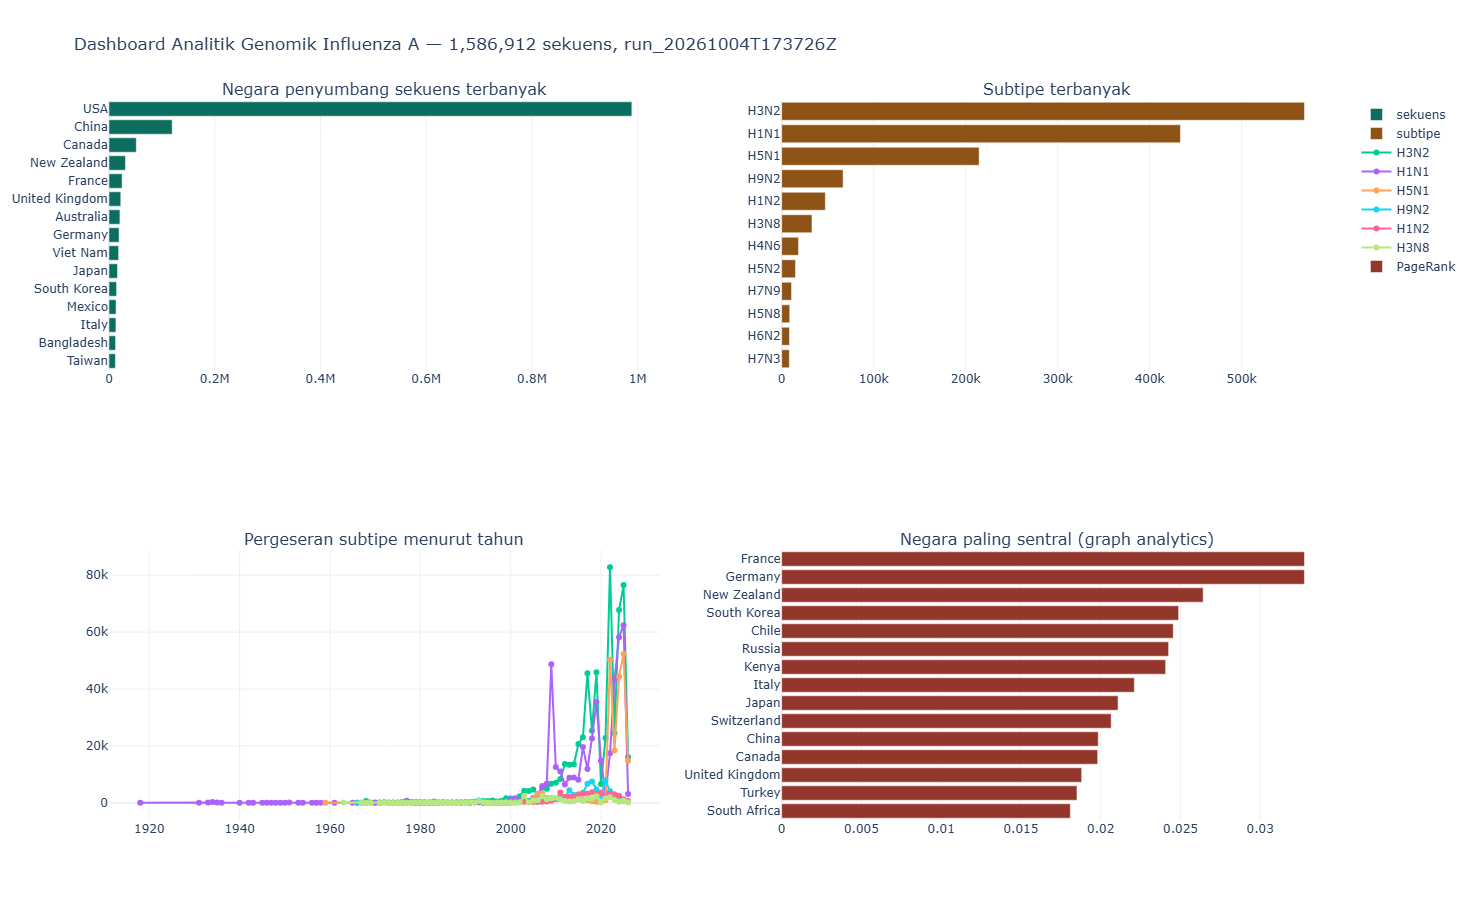

[<] OK | 2.0 detik | RAM bebas 23.9 GB


In [10]:
with Tahap("bangun dashboard interaktif", "VISUALISASI"):
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import plotly.io as pio

    neg = top_neg
    sub = top_sub

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=("Negara penyumbang sekuens terbanyak",
                        "Subtipe terbanyak",
                        "Pergeseran subtipe menurut tahun",
                        "Negara paling sentral (graph analytics)"),
        specs=[[{"type": "bar"}, {"type": "bar"}],
               [{"type": "scatter"}, {"type": "bar"}]])

    fig.add_trace(go.Bar(x=neg["count"], y=neg["negara"], orientation="h",
                         marker_color="#0B6E5F", name="sekuens"), row=1, col=1)
    fig.add_trace(go.Bar(x=sub["count"], y=sub["subtipe"], orientation="h",
                         marker_color="#8E5417", name="subtipe"), row=1, col=2)

    for s in sub["subtipe"].head(6):
        d = per_tahun[per_tahun["subtipe"] == s]
        fig.add_trace(go.Scatter(x=d["tahun_koleksi"], y=d["count"],
                                 mode="lines+markers", name=s), row=2, col=1)

    if geo_sentral is not None:
        g = geo_sentral.orderBy(F.desc("skor")).limit(15).toPandas()
        fig.add_trace(go.Bar(x=g["skor"], y=g["id"], orientation="h",
                             marker_color="#93362B", name="PageRank"), row=2, col=2)

    fig.update_layout(
        height=900, showlegend=True,
        title_text="Dashboard Analitik Genomik Influenza A — "
                   f"{silver.count():,} sekuens, {RUN_ID}",
        template="plotly_white")
    fig.update_yaxes(autorange="reversed", row=1, col=1)
    fig.update_yaxes(autorange="reversed", row=1, col=2)
    fig.update_yaxes(autorange="reversed", row=2, col=2)

    berkas = OUT / "dashboard.html"
    pio.write_html(fig, file=str(berkas), include_plotlyjs="cdn", full_html=True)
    print(f"  Dashboard disimpan: {berkas}")
    print("  Buka dari Windows di D:\\BDA\\output\\dashboard.html")
    fig.show()


In [11]:
with Tahap("ringkasan akhir proyek", "MONITORING"):
    print("=" * 66)
    print("  RINGKASAN PIPELINE")
    print("=" * 66)
    print(f"  Sekuens dalam zona silver : {silver.count():,}")
    for nama, p in [("metrik model", BASE / "models" / "metrik_model.csv"),
                    ("skalabilitas", BASE / "models" / "metrik_skalabilitas.csv"),
                    ("ringkasan graf", BASE / "graph" / "ringkasan_graf.json"),
                    ("kualitas data", BASE / "stage" / "laporan_kualitas.json")]:
        print(f"  {nama:<26} {'ADA' if p.exists() else 'belum'}")
    print("\n  Gambar untuk laporan:")
    for g in sorted(OUT.glob("*.png")):
        print(f"    {g.name}")
    print("\n  Dashboard: output/dashboard.html")
    print("  Tabel mart: MySQL bda_influenza")

display(ringkas_zona())
display(jejak_df())
stop_spark()
print("\nSELESAI. Seluruh pipeline 01-07 telah dijalankan.")



--------------------------------------------------------------------
[>] MONITORING | ringkasan akhir proyek
  RINGKASAN PIPELINE
  Sekuens dalam zona silver : 1,586,912
  metrik model               ADA
  skalabilitas               ADA
  ringkasan graf             ADA
  kualitas data              ADA

  Gambar untuk laporan:
    graf_reassortment.png
    insight1_geografi.png
    insight2_ml.png
    insight3_graf.png
    kurva_konvergensi.png
    kurva_konvergensi_tugas_a.png
    kurva_skalabilitas.png

  Dashboard: output/dashboard.html
  Tabel mart: MySQL bda_influenza
[<] OK | 0.1 detik | RAM bebas 23.9 GB


,zona,isi,ukuran
0,lake/fasta,152,162.2 MB
1,lake/meta_csv,49,367.6 MB
2,stage,1,1.3 KB
3,features,1,735.0 B
4,models,4,2.2 KB
5,graph,1,1.5 KB
6,mart,0,0.0 B
7,output,8,933.2 KB


,run_id,lapisan,tahap,status,detik,ram_delta_gb,ram_bebas_gb,waktu
0,run_20261004T173726Z,WAREHOUSE,uji koneksi MySQL,OK,6.19,0.22,30.0,2026-10-04T17:37:51.989676+00:00
1,run_20261004T173726Z,WAREHOUSE,baca hasil seluruh tahap,OK,7.09,1.06,28.9,2026-10-04T17:37:59.099694+00:00
2,run_20261004T173726Z,WAREHOUSE,bangun dan tulis tabel mart,OK,11.30,3.65,25.2,2026-10-04T17:38:10.418320+00:00
3,run_20261004T173726Z,WAREHOUSE,tulis hasil ML dan graf ke MySQL,OK,4.03,0.51,24.7,2026-10-04T17:38:14.460776+00:00
4,run_20261004T173726Z,WAREHOUSE,verifikasi isi MySQL,OK,0.15,0.03,24.7,2026-10-04T17:38:14.622021+00:00
5,run_20261004T173726Z,VISUALISASI,INSIGHT 1 -- geografi dan waktu,OK,3.20,0.39,24.3,2026-10-04T17:38:18.204117+00:00
6,run_20261004T173726Z,VISUALISASI,INSIGHT 2 -- machine learning,OK,0.39,0.03,24.3,2026-10-04T17:38:18.617320+00:00
7,run_20261004T173726Z,VISUALISASI,INSIGHT 3 -- graph analytics,OK,0.86,0.02,24.3,2026-10-04T17:38:19.494070+00:00
8,run_20261004T173726Z,VISUALISASI,bangun dashboard interaktif,OK,1.95,0.36,23.9,2026-10-04T17:38:21.456145+00:00
9,run_20261004T173726Z,MONITORING,ringkasan akhir proyek,OK,0.15,0.00,23.9,2026-10-04T17:38:21.613617+00:00


Spark dihentikan. Proses Java tersisa: 9

SELESAI. Seluruh pipeline 01-07 telah dijalankan.
